# Desempenho comercial e perfis de clientes

Começando a análise.

Objetivo: identificar os perfis de clientes, os principais motores de receita e oportunidades práticas de melhoria comercial.

## A base foi lida corretamente?
Vamos validar dimensões, tipos, rótulos e uma amostra antes de calcular os indicadores.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
df = pd.read_csv('../../data/Datasets/Sales/supermarket_sales.csv', parse_dates=['Date'])
df.shape, df.dtypes.to_frame('tipo'), df.head()

((1000, 17),
                                    tipo
 Invoice ID                          str
 Branch                              str
 City                                str
 Customer type                       str
 Gender                              str
 Product line                        str
 Unit price                      float64
 Quantity                          int64
 Tax 5%                          float64
 Total                           float64
 Date                     datetime64[us]
 Time                                str
 Payment                             str
 cogs                            float64
 gross margin percentage         float64
 gross income                    float64
 Rating                          float64,
     Invoice ID Branch       City Customer type  Gender  \
 0  750-67-8428      A     Yangon        Member  Female   
 1  226-31-3081      C  Naypyitaw        Normal  Female   
 2  631-41-3108      A     Yangon        Normal    Male   
 3  123-19-1

**Verificação de leitura:** o CSV possui 1.000 compras, 17 colunas, rótulos legíveis e datas convertidas. Não há ausência de dados; `Tax 5%` e `gross income` são iguais na base e serão tratados como a mesma métrica econômica, sem somar os dois.

In [2]:
COR_PRIMARIA='#0072B2'; COR_SECUNDARIA='#94A3B8'; COR_DESTAQUE='#E69F00'; COR_VERDE='#009E73'; COR_EIXO='#B0B7C3'; COR_TEXTO='#334155'
PALETA=['#0072B2','#E69F00','#009E73','#CC79A7','#56B4E9','#D55E00']
plt.rcParams.update({'figure.figsize':(10,6),'figure.dpi':110,'font.size':11,'text.color':COR_TEXTO,'axes.titlesize':15,'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False,'axes.grid':False,'axes.prop_cycle':plt.cycler(color=PALETA)})
def reais(v): return f'R$ {v:,.2f}'.replace(',','X').replace('.',',').replace('X','.')

## Qual é o tamanho econômico da operação?
Vamos estabelecer os indicadores de referência para receita, margem, volume e experiência.

In [3]:
kpis = pd.DataFrame({'compras':[len(df)],'receita_total':[df['Total'].sum()],'ticket_medio':[df['Total'].mean()],'lucro_bruto_total':[df['gross income'].sum()],'margem_sobre_receita':[df['gross income'].sum()/df['Total'].sum()],'avaliacao_media':[df['Rating'].mean()]})
kpis

,compras,receita_total,ticket_medio,lucro_bruto_total,margem_sobre_receita,avaliacao_media
0,1000,"322,966.75",322.97,"15,379.37",0.05,6.97


**Leitura executiva:** a operação tem margem unitária estreita, portanto o crescimento de receita precisa vir de mais compras, maior quantidade por compra e melhor mix de produtos — não apenas de aumento de preço.

## Quais categorias sustentam receita e margem?
Vamos comparar receita, ticket, quantidade e margem bruta por linha de produto.

In [4]:
por_produto = df.groupby('Product line').agg(compras=('Invoice ID','count'), receita=('Total','sum'), ticket=('Total','mean'), margem=('gross income','sum'), avaliacao=('Rating','mean')).sort_values('receita', ascending=False)
por_produto

,compras,receita,ticket,margem,avaliacao
Product line,,,,,
Food and beverages,174,"56,144.84",322.67,"2,673.56",7.11
Sports and travel,166,"55,122.83",332.07,"2,624.90",6.92
Electronic accessories,170,"54,337.53",319.63,"2,587.50",6.92
Fashion accessories,178,"54,305.89",305.09,"2,585.99",7.03
Home and lifestyle,160,"53,861.91",336.64,"2,564.85",6.84
Health and beauty,152,"49,193.74",323.64,"2,342.56",7.00


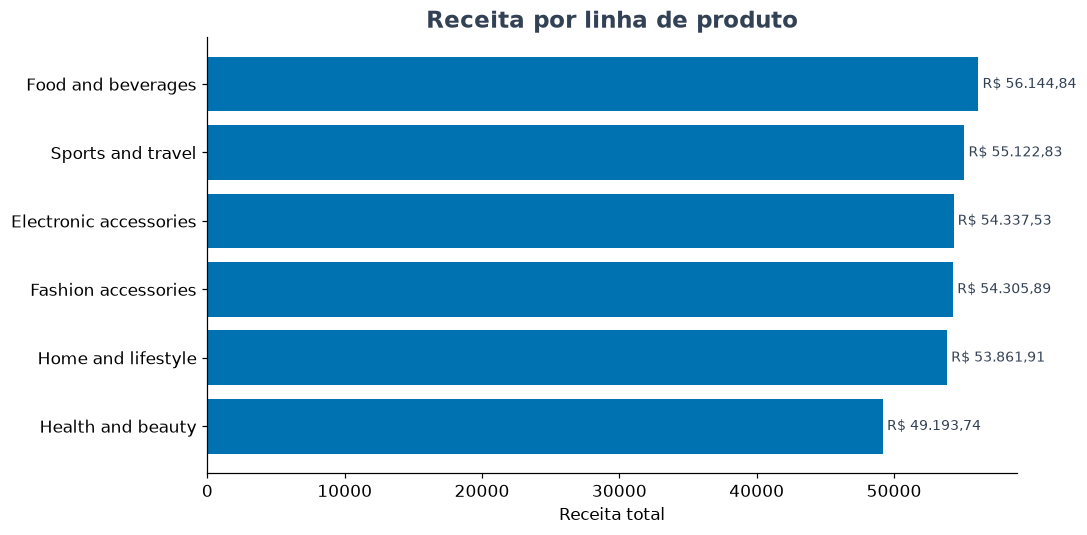

In [5]:
fig, ax = plt.subplots(figsize=(10,5))
dados = por_produto['receita'].sort_values()
ax.barh(dados.index, dados.values, color=COR_PRIMARIA)
for i,v in enumerate(dados.values): ax.text(v+300, i, reais(v), va='center', fontsize=9)
ax.set(title='Receita por linha de produto', xlabel='Receita total', ylabel='')
plt.tight_layout()

**Revisão crítica:** receita mede contribuição absoluta, não rentabilidade percentual. A decisão de priorização deve cruzar receita, margem e avaliação; uma categoria líder pode ser grande sem ser a melhor oportunidade incremental.

## Qual filial apresenta maior oportunidade?
Vamos comparar desempenho por filial/cidade, controlando pelo número de compras.

In [6]:
por_filial = df.groupby(['Branch','City']).agg(compras=('Invoice ID','count'), receita=('Total','sum'), ticket=('Total','mean'), margem=('gross income','sum'), avaliacao=('Rating','mean')).sort_values('receita', ascending=False)
por_filial

,,compras,receita,ticket,margem,avaliacao
Branch,City,,,,,
C,Naypyitaw,328,"110,568.71",337.10,"5,265.18",7.07
A,Yangon,340,"106,200.37",312.35,"5,057.16",7.03
B,Mandalay,332,"106,197.67",319.87,"5,057.03",6.82


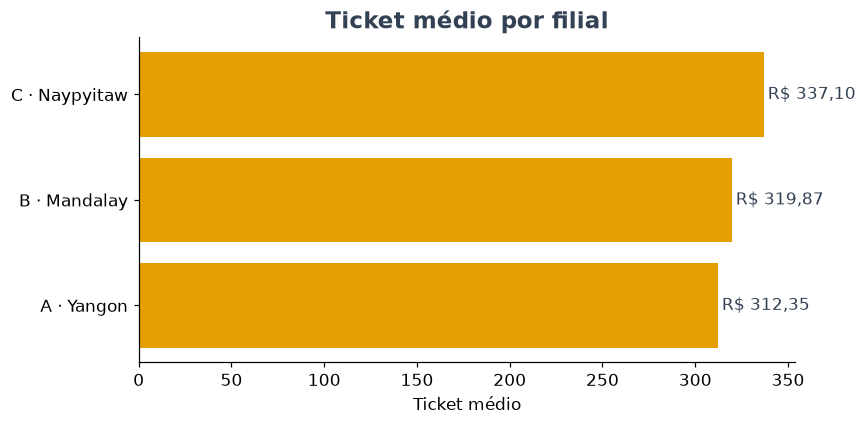

In [7]:
fig, ax = plt.subplots(figsize=(8,4))
dados = por_filial['ticket'].sort_values()
ax.barh([f'{b} · {c}' for b,c in dados.index], dados.values, color=COR_DESTAQUE)
for i,v in enumerate(dados.values): ax.text(v+2, i, reais(v), va='center')
ax.set(title='Ticket médio por filial', xlabel='Ticket médio', ylabel='')
plt.tight_layout()

**Revisão crítica:** diferenças de ticket devem ser lidas junto do número de compras e do mix de categorias. O resultado indica oportunidade comercial, mas não prova que a filial ou cidade seja a causa do desempenho.

## Como os perfis Member e Normal se comportam?
Vamos comparar tamanho, frequência observada, ticket, quantidade, receita e avaliação por tipo de cliente.

In [8]:
perfil = df.groupby('Customer type').agg(compras=('Invoice ID','count'), receita=('Total','sum'), ticket=('Total','mean'), quantidade_media=('Quantity','mean'), avaliacao=('Rating','mean'), margem=('gross income','sum'))
perfil['participacao_receita'] = perfil['receita'] / df['Total'].sum()
perfil

,compras,receita,ticket,quantidade_media,avaliacao,margem,participacao_receita
Customer type,,,,,,,
Member,501,"164,223.44",327.79,5.56,6.94,"7,820.16",0.51
Normal,499,"158,743.30",318.12,5.46,7.01,"7,559.20",0.49


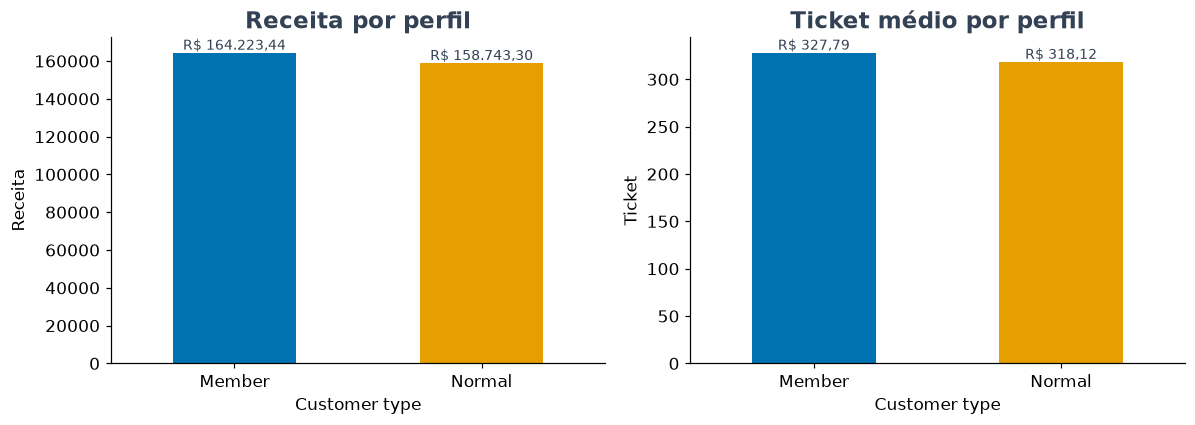

In [9]:
fig, axes = plt.subplots(1,2,figsize=(11,4))
perfil['receita'].plot.bar(ax=axes[0], color=[COR_PRIMARIA,COR_DESTAQUE], rot=0)
axes[0].set(title='Receita por perfil', ylabel='Receita')
for p in axes[0].patches: axes[0].annotate(reais(p.get_height()), (p.get_x()+p.get_width()/2,p.get_height()), ha='center', va='bottom', fontsize=9)
perfil['ticket'].plot.bar(ax=axes[1], color=[COR_PRIMARIA,COR_DESTAQUE], rot=0)
axes[1].set(title='Ticket médio por perfil', ylabel='Ticket')
for p in axes[1].patches: axes[1].annotate(reais(p.get_height()), (p.get_x()+p.get_width()/2,p.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()

**Revisão crítica:** `Member` e `Normal` são grupos observados em transações, não clientes identificados individualmente. Como não existe um ID de cliente, não é possível medir retenção, frequência por pessoa ou conversão de cadastro.

## Quais horários concentram as vendas?
Vamos identificar janelas de maior movimento para orientar escala, campanhas e ofertas.

In [10]:
df['hour'] = pd.to_datetime(df['Time']).dt.hour
por_hora = df.groupby('hour').agg(compras=('Invoice ID','count'), receita=('Total','sum'), ticket=('Total','mean')).sort_values('receita', ascending=False)
por_hora.head(5)

/var/folders/x2/yjty72zn4916zsbt7mnqzxjc0000gn/T/ipykernel_6678/3194175150.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['Time']).dt.hour


,compras,receita,ticket
hour,,,
19,113,"39,699.51",351.32
13,103,"34,723.23",337.12
10,101,"31,421.48",311.10
15,102,"31,179.51",305.68
14,83,"30,828.40",371.43


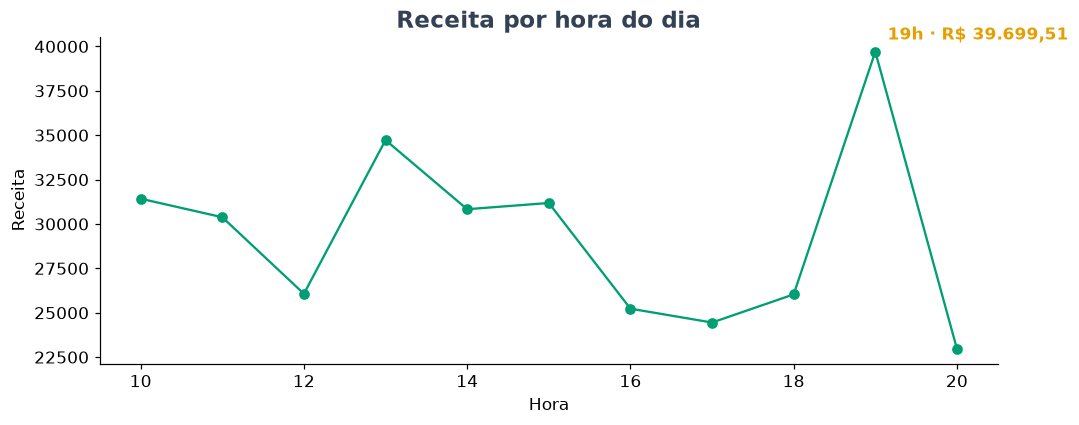

In [11]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(por_hora.sort_index().index, por_hora.sort_index()['receita'], color=COR_VERDE, marker='o')
pico = por_hora['receita'].idxmax(); valor = por_hora.loc[pico,'receita']
ax.annotate(f'{pico}h · {reais(valor)}', (pico,valor), xytext=(8,8), textcoords='offset points', color=COR_DESTAQUE, fontweight='bold')
ax.set(title='Receita por hora do dia', xlabel='Hora', ylabel='Receita'); plt.tight_layout()

## Síntese executiva e plano de melhoria
**Achados:** use os rankings de produto e filial para concentrar ações onde há receita e margem observáveis. Compare `Member` e `Normal` por ticket e participação para desenhar benefícios que elevem quantidade por compra. Use os horários de pico para escala e horários de menor movimento para campanhas.

**Limitações:** o arquivo cobre apenas três meses, não possui cliente individual, custo operacional, estoque, promoções ou histórico anterior. Os resultados são associações descritivas e não permitem afirmar causalidade.

**Plano recomendado:** (1) criar identificação de cliente e acompanhar recorrência; (2) testar bundles entre categorias com bom ticket e boa avaliação; (3) ativar campanhas em horários de menor movimento; (4) definir metas por filial para ticket, quantidade e margem; (5) repetir a análise mensalmente com dados de estoque, promoções e custo.